In [2]:
import numpy as np
from functools import reduce

# --- 1. Fungsi Bikin Matriks Pauli (Operator P) ---
def get_pauli_tensor(pauli_string):
    I = np.array([[1, 0], [0, 1]], dtype=complex)
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    mapping = {'I': I, 'X': X, 'Y': Y, 'Z': Z}
    
    matrices = [mapping[char] for char in pauli_string.upper()]
    return reduce(np.kron, matrices)

# --- 2. Fungsi Bikin Matriks Ansatz (Operator U) ---
def get_ry_matrix(theta):
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    return np.array([[c, -s], [s, c]], dtype=complex)

def get_ansatz_matrix(thetas):
    # Definisi gate dasar
    I = np.eye(2, dtype=complex)
    CX = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)
    
    # Bikin Operator Entanglement (Linear: 0-1, 1-2, 2-3)
    CX_01 = np.kron(CX, np.kron(I, I))
    CX_12 = np.kron(I, np.kron(CX, I))
    CX_23 = np.kron(I, np.kron(I, CX))
    U_entangle = CX_23 @ CX_12 @ CX_01

    # Layer 1 (Rotasi)
    L1 = get_ry_matrix(thetas[0])
    for i in range(1, 4): L1 = np.kron(L1, get_ry_matrix(thetas[i]))
    
    # Layer 2 (Rotasi)
    L2 = get_ry_matrix(thetas[4])
    for i in range(5, 8): L2 = np.kron(L2, get_ry_matrix(thetas[i]))
    
    # Layer 3 (Rotasi)
    L3 = get_ry_matrix(thetas[8])
    for i in range(9, 12): L3 = np.kron(L3, get_ry_matrix(thetas[i]))
    
    # Total U
    return L3 @ U_entangle @ L2 @ U_entangle @ L1

def exp_val(target_pauli):
    # ==========================================
    # MAIN PROGRAM (SIMULASI TUGAS AKHIR)
    # ==========================================

    # A. Setup Parameter & Operator
    # Misal: Operator Pauli yang mau dihitung variansinya

    # Misal: Parameter Theta (12 angka acak)
    # Dalam ML/QEM, angka ini biasanya datang dari optimizer
    thetas =  np.random.uniform(-np.pi, np.pi, size=12)

    # B. Construct Matriks
    P = get_pauli_tensor(target_pauli)  # Matriks 16x16
    U = get_ansatz_matrix(thetas)       # Matriks 16x16

    # C. Definisi State Awal |0000>
    # Vektor ukuran 16, elemen pertama 1, sisanya 0
    state_nol = np.zeros((16, 1), dtype=complex)
    state_nol[0, 0] = 1.0

    # D. Hitung State Akhir |psi>
    # |psi> = U * |0>
    psi = U @ state_nol 

    # E. Hitung Ekspektasi & Variansi
    # Rumus: <psi | P | psi>
    # np.vdot otomatis melakukan conjugate transpose pada argumen pertama (psi dagger)
    expectation_val = np.vdot(psi, P @ psi).real # Ambil bagian real (karena observable pasti real)

    # Rumus Variansi: 1 - <P>^2
    variance_val = 1.0 - (expectation_val ** 2)
    
    return variance_val

In [3]:
def exp_mean(pauli_string):
    exp_vals = []
    for i in range(5000):
        exp_vals.append(exp_val(pauli_string))

    return sum(exp_vals)/len(exp_vals)

In [4]:
hamiltonian = ['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ',
               'ZIII', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII']
exp_means = []
for pauli_str in hamiltonian:
    exp_means.append({'pauli_string' : pauli_str, 'exp_mean' : exp_mean(pauli_str)})    

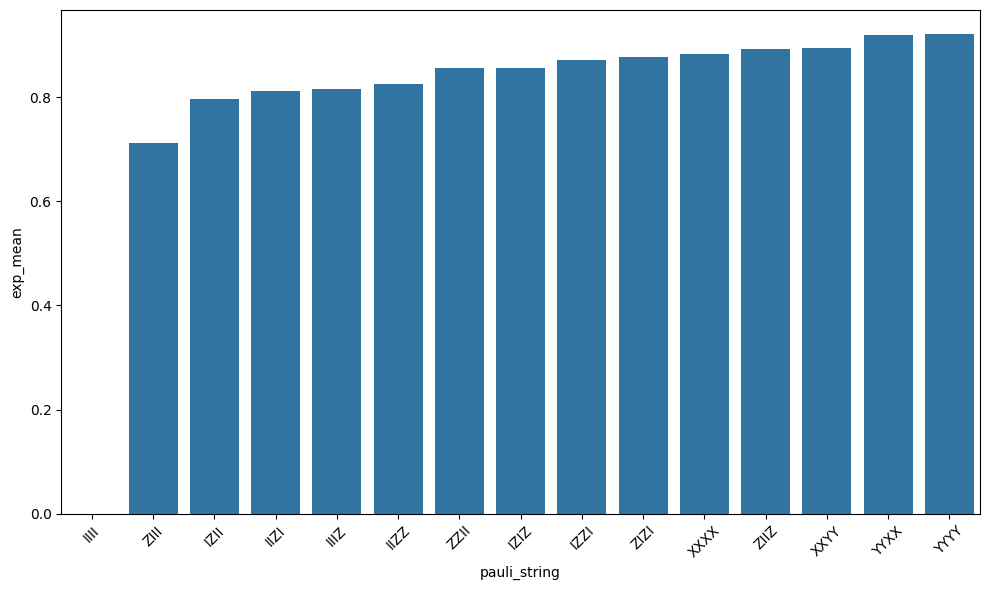

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 

var_df = pd.DataFrame(exp_means).sort_values(by='exp_mean', ascending=True)

# 3. Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=var_df, x='pauli_string', y='exp_mean')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Qiskit

In [1]:
import numpy as np
from functools import reduce

# --- 1. Fungsi Bikin Matriks Pauli (Little-Endian) ---
def get_pauli_tensor_le(pauli_string):
    """
    Input: "ZIXY" (artinya Z pada q0, I pada q1, dst)
    Output: Matriks Tensor dengan urutan q3 x q2 x q1 x q0
    """
    I = np.array([[1, 0], [0, 1]], dtype=complex)
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    mapping = {'I': I, 'X': X, 'Y': Y, 'Z': Z}
    
    # Ambil matriks sesuai string
    matrices = [mapping[char] for char in pauli_string.upper()]
    
    # PENTING: Kita balik urutannya (q3...q0) sebelum di-reduce
    # Jadi tensornya: P_3 ⊗ P_2 ⊗ P_1 ⊗ P_0
    return reduce(np.kron, matrices)

# --- 2. Fungsi Bikin Matriks Ansatz (Little-Endian) ---
def get_ry_matrix(theta):
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    return np.array([[c, -s], [s, c]], dtype=complex)

def get_ansatz_matrix_le(thetas):
    I = np.eye(2, dtype=complex)
    
    # --- Definisi CNOT Spesial (Reverse CNOT) ---
    # Standar CX (Top-Control, Bottom-Target) -> |c>|t>
    # Karena Little Endian: Target(q1) x Control(q0)
    # Maka kita butuh matriks dimana Control-nya ada di bit "bawah/kanan"
    # Mapping: 
    # |00> -> |00>
    # |01> (c=1, t=0) -> |11> (Target flip jadi 1)
    # |10> (c=0, t=1) -> |10>
    # |11> (c=1, t=1) -> |01> (Target flip jadi 0)
    
    CX_reversed = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 1], # 01 jadi 11
        [0, 0, 1, 0],
        [0, 1, 0, 0]  # 11 jadi 01
    ], dtype=complex)
    
    # --- Layer Entanglement ---
    # Urutan Tensor Global: q3 ⊗ q2 ⊗ q1 ⊗ q0
    
    # CX 0->1: Melibatkan q1, q0 (paling kanan). 
    # Struktur: I_3 ⊗ I_2 ⊗ CX_rev(q1, q0)
    CX_01 = np.kron(I, np.kron(I, CX_reversed))
    
    # CX 1->2: Melibatkan q2, q1 (tengah).
    # Struktur: I_3 ⊗ CX_rev(q2, q1) ⊗ I_0
    CX_12 = np.kron(I, np.kron(CX_reversed, I))
    
    # CX 2->3: Melibatkan q3, q2 (paling kiri).
    # Struktur: CX_rev(q3, q2) ⊗ I_1 ⊗ I_0
    CX_23 = np.kron(CX_reversed, np.kron(I, I))
    
    # Total operator Entangle (urutan 0->1, 1->2, 2->3)
    U_entangle = CX_23 @ CX_12 @ CX_01

    # --- Layer Rotasi Ry ---
    # Kita menyusun tensor product dari q3 sampai q0 (mundur)
    
    # Layer 1 (theta 0-3)
    # Tensor: Ry(th3) ⊗ Ry(th2) ⊗ Ry(th1) ⊗ Ry(th0)
    L1 = get_ry_matrix(thetas[3])
    for i in range(2, -1, -1): # Loop mundur: 2, 1, 0
        L1 = np.kron(L1, get_ry_matrix(thetas[i]))
        
    # Layer 2 (theta 4-7)
    L2 = get_ry_matrix(thetas[7])
    for i in range(6, 3, -1): # Loop mundur: 6, 5, 4
        L2 = np.kron(L2, get_ry_matrix(thetas[i]))
        
    # Layer 3 (theta 8-11)
    L3 = get_ry_matrix(thetas[11])
    for i in range(10, 7, -1): # Loop mundur: 10, 9, 8
        L3 = np.kron(L3, get_ry_matrix(thetas[i]))
    
    # Perkalian Matriks Total
    return L3 @ U_entangle @ L2 @ U_entangle @ L1

# ==========================================
# SIMULASI (Little Endian Version)
# ==========================================

def exp_val_le(target_pauli):
    # ==========================================
    # MAIN PROGRAM (SIMULASI TUGAS AKHIR)
    # ==========================================

    # A. Setup Parameter & Operator
    # Misal: Operator Pauli yang mau dihitung variansinya

    # Misal: Parameter Theta (12 angka acak)
    # Dalam ML/QEM, angka ini biasanya datang dari optimizer
    thetas =  np.random.uniform(-np.pi, np.pi, size=12)

    # B. Construct Matriks
    P = get_pauli_tensor_le(target_pauli)  # Matriks 16x16
    U = get_ansatz_matrix_le(thetas)       # Matriks 16x16

    # C. Definisi State Awal |0000>
    # Vektor ukuran 16, elemen pertama 1, sisanya 0
    state_nol = np.zeros((16, 1), dtype=complex)
    state_nol[0, 0] = 1.0

    # D. Hitung State Akhir |psi>
    # |psi> = U * |0>
    psi = U @ state_nol 

    # E. Hitung Ekspektasi & Variansi
    # Rumus: <psi | P | psi>
    # np.vdot otomatis melakukan conjugate transpose pada argumen pertama (psi dagger)
    expectation_val = np.vdot(psi, P @ psi).real # Ambil bagian real (karena observable pasti real)

    # Rumus Variansi: 1 - <P>^2
    variance_val = np.sqrt(1.0 - (expectation_val ** 2))
    
    return variance_val

In [2]:
def exp_mean_le(pauli_string):
    exp_vals_le = []
    for i in range(5000):
        val = (exp_val_le(pauli_string))**2
        exp_vals_le.append(val)

    return np.square(sum(exp_vals_le))

In [3]:
hamiltonian = ['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ',
               'ZIII', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII']
exp_means_le = []
for pauli_str in hamiltonian:
    exp_means_le.append({'pauli_string' : pauli_str, 'exp_mean' : exp_mean_le(pauli_str)})    

/tmp/ipykernel_1701/599426694.py:124: RuntimeWarning: invalid value encountered in sqrt
  variance_val = np.sqrt(1.0 - (expectation_val ** 2))


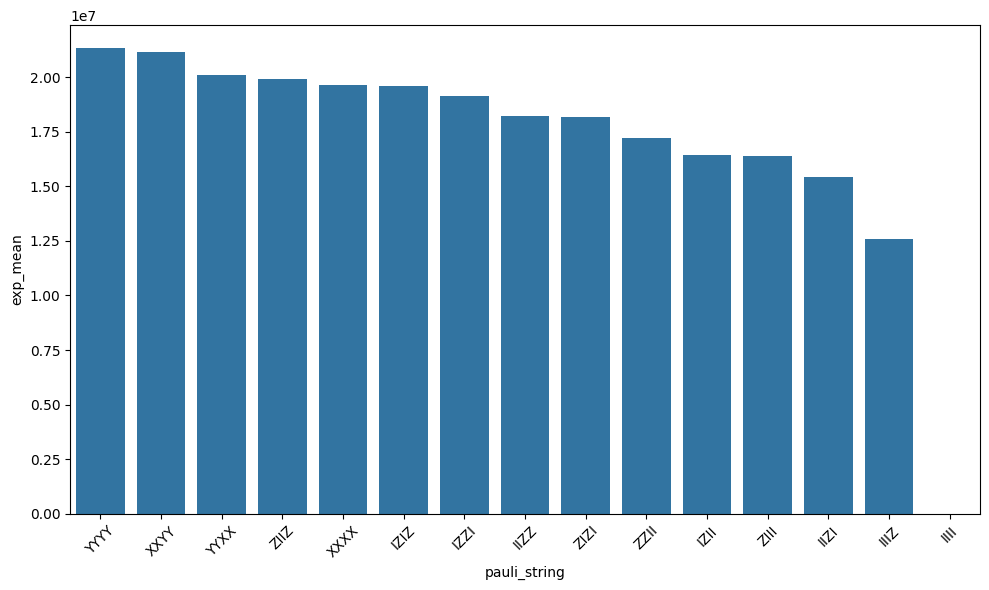

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 

var_df_le = pd.DataFrame(exp_means_le).sort_values(by='exp_mean', ascending=False)

# 3. Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=var_df_le, x='pauli_string', y='exp_mean')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()